<a href="https://colab.research.google.com/github/Jstein123/Lecture-3-code/blob/main/Jared_Stein_DOU_One.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DOU 1: Regional Temperature Patterns with pandas

**Goal:** clean, combine, and analyze daily temperature measurements from a network of weather stations to investigate regional differences, seasonal variation, and longer term trends.

**Data files**:
- `weather_stations.csv`: one row per station (metadata)
- `temperature_data.csv`: one row per station per day (measurements)

The notebook follows the assignment structure: Part 1 (exploration), Part 2 (cleaning), Part 3 (joining), Part 4 (aggregation), Part 5 (time series).

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings so wide tables are readable
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
pd.set_option("display.precision", 2)

---
## Part 1: Data Loading and Initial Exploration

I load both files without parsing dates yet. That way I see the data exactly as it arrives, and the date conversion is an explicit, documented cleaning step in Part 2.

In [63]:
stations_raw = pd.read_csv("weather_stations.csv")
temps_raw = pd.read_csv("temperature_data.csv")

print("weather_stations shape:", stations_raw.shape)
print("temperature_data shape:", temps_raw.shape)

weather_stations shape: (25, 7)
temperature_data shape: (54975, 6)


### 1.1 Weather stations: structure

In [64]:
stations_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   station_id         25 non-null     object 
 1   station_name       24 non-null     object 
 2   latitude           25 non-null     float64
 3   longitude          25 non-null     float64
 4   elevation_m        24 non-null     float64
 5   region             25 non-null     object 
 6   installation_date  25 non-null     object 
dtypes: float64(3), object(4)
memory usage: 1.5+ KB


In [65]:
stations_raw

,station_id,station_name,latitude,longitude,elevation_m,region,installation_date
0,ST001,Mountain View,37.99,-80.74,2908.75,East,2015-01-01
1,ST002,Coastal Point,47.21,-110.02,2325.40,East,2015-02-15
2,ST003,River Valley,43.71,-94.29,2818.50,North,2015-04-01
3,ST004,Desert Plains,41.58,-90.38,NaN,East,2015-05-16
4,ST005,Forest Ridge,34.50,-117.68,1793.70,Central,2015-06-30
5,ST006,Lake Shore,34.50,-89.62,2765.62,South,2015-08-14
6,ST007,Urban Center,32.93,-111.47,265.48,South,2015-09-28
7,ST008,Prairie Fields,45.86,-116.75,587.95,North,2015-11-12
8,ST009,Canyon Rim,41.62,-72.56,135.68,West,2015-12-27
9,ST010,Bay Harbor,43.33,-71.72,975.99,North,2016-02-10


In [66]:
stations_raw.describe()

,latitude,longitude,elevation_m
count,25.00,25.00,24.00
mean,39.05,-97.45,1503.94
std,4.56,14.91,1010.42
min,32.33,-118.28,16.57
25%,34.93,-110.76,594.10
50%,37.99,-95.24,1397.06
75%,41.79,-86.87,2416.54
max,47.52,-71.72,2960.66


### 1.2 Temperature data: structure

In [67]:
temps_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54975 entries, 0 to 54974
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   station_id    54975 non-null  object 
 1   date          54975 non-null  object 
 2   temp_max_c    54975 non-null  float64
 3   temp_min_c    54975 non-null  float64
 4   temp_avg_c    54475 non-null  float64
 5   data_quality  52105 non-null  object 
dtypes: float64(3), object(3)
memory usage: 2.5+ MB


In [68]:
temps_raw.head()

,station_id,date,temp_max_c,temp_min_c,temp_avg_c,data_quality
0,ST024,2022-01-14,10.6,0.7,6.0,good
1,ST008,2018-10-03,27.5,20.1,24.0,good
2,ST011,2019-05-06,26.8,17.9,22.7,NaN
3,ST019,2021-07-23,46.8,35.5,43.4,good
4,ST014,2021-02-17,17.4,8.1,14.3,good


In [69]:
temps_raw.describe()

,temp_max_c,temp_min_c,temp_avg_c
count,54975.00,54975.00,54475.00
mean,28.51,17.51,23.02
std,12.48,12.47,12.39
min,-6.00,-15.80,-9.40
25%,18.60,7.50,13.10
50%,28.60,17.50,23.10
75%,38.10,27.10,32.50
max,64.00,54.10,58.30


### 1.3 The `data_quality` flag

The data dictionary says the flag should be one of `good`, `fair`, `poor`, or `missing`. I use `dropna=False` so that absent flags are counted too.

In [70]:
temps_raw["data_quality"].value_counts(dropna=False)

,count
data_quality,
good,38467
fair,10951
NaN,2870
poor,2687


There is no literal `"missing"` label. Instead, the flag itself is missing (`NaN`) for some rows. I treat a `NaN` flag as the "missing" category from the data dictionary but we have no information about how reliable those readings are.

### 1.4 Missing values (count and percentage per column)

I wrote a small helper function because I need the same table for both datasets.

In [71]:
def missing_summary(df):
    """Return count and percentage of missing values for each column."""
    return pd.DataFrame({
        "n_missing": df.isna().sum(),
        "pct_missing": (df.isna().mean() * 100).round(2),
    })

print("weather_stations.csv")
display(missing_summary(stations_raw))
print("temperature_data.csv")
display(missing_summary(temps_raw))

weather_stations.csv


,n_missing,pct_missing
station_id,0,0.0
station_name,1,4.0
latitude,0,0.0
longitude,0,0.0
elevation_m,1,4.0
region,0,0.0
installation_date,0,0.0


temperature_data.csv


,n_missing,pct_missing
station_id,0,0.00
date,0,0.00
temp_max_c,0,0.00
temp_min_c,0,0.00
temp_avg_c,500,0.91
data_quality,2870,5.22


In [72]:
# Which station rows have missing metadata?
stations_raw[stations_raw.isna().any(axis=1)]

,station_id,station_name,latitude,longitude,elevation_m,region,installation_date
3,ST004,Desert Plains,41.58,-90.38,NaN,East,2015-05-16
17,ST018,NaN,40.40,-118.28,2406.59,East,2017-02-04


### 1.5 Duplicates

In [73]:
# Duplicates as defined as same station on the same date
key_dupes = temps_raw.duplicated(subset=["station_id", "date"]).sum()
# Completely identical rows
full_dupes = temps_raw.duplicated().sum()

print(f"Extra rows sharing a (station_id, date) key: {key_dupes}")
print(f"Extra rows that are exact copies:          {full_dupes}")

Extra rows sharing a (station_id, date) key: 200
Extra rows that are exact copies:          199


In [74]:
# The two counts differ by one, so one key-duplicate pair is not identical.
# Find the (station_id, date) groups whose rows disagree on some column.
dupe_rows = temps_raw[temps_raw.duplicated(subset=["station_id", "date"], keep=False)]
disagreements = (
    dupe_rows.groupby(["station_id", "date"])
    .nunique(dropna=False)
    .loc[lambda d: (d > 1).any(axis=1)]
)
disagreements

,,temp_max_c,temp_min_c,temp_avg_c,data_quality
station_id,date,,,,
ST020,2019-04-17,1,1,2,1


In [75]:
dupe_rows.merge(disagreements.reset_index()[["station_id", "date"]], on=["station_id", "date"])

,station_id,date,temp_max_c,temp_min_c,temp_avg_c,data_quality
0,ST020,2019-04-17,42.4,28.2,NaN,poor
1,ST020,2019-04-17,42.4,28.2,35.0,poor


### 1.6 Consistency and plausibility checks

In [76]:
# Do the station IDs agree between the two files?
ids_in_temps = set(temps_raw["station_id"])
ids_in_stations = set(stations_raw["station_id"])
print("Stations in temperature data but not in station file:", ids_in_temps - ids_in_stations)
print("Stations in station file but with no temperature data:", ids_in_stations - ids_in_temps)
print("Is station_id unique in the station file?", stations_raw["station_id"].is_unique)

Stations in temperature data but not in station file: set()
Stations in station file but with no temperature data: set()
Is station_id unique in the station file? True


In [77]:
# Internal consistency of the temperature values
print("Rows where max < min:", (temps_raw["temp_max_c"] < temps_raw["temp_min_c"]).sum())
outside = (temps_raw["temp_avg_c"] > temps_raw["temp_max_c"]) | (temps_raw["temp_avg_c"] < temps_raw["temp_min_c"])
print("Rows where avg is outside [min, max]:", outside.sum())
print("Highest recorded max temperature:", temps_raw["temp_max_c"].max(), "°C")
print("Rows with max temperature above 50 °C:", (temps_raw["temp_max_c"] > 50).sum())

Rows where max < min: 0
Rows where avg is outside [min, max]: 0
Highest recorded max temperature: 64.0 °C
Rows with max temperature above 50 °C: 2057


In [78]:
# Records per station
temps_raw["station_id"].value_counts().describe()

,count
count,25.00
mean,2199.00
std,2.99
min,2193.00
25%,2197.00
50%,2198.00
75%,2201.00
max,2205.00


### 1.7 Answers to the Part 1 questions

In [79]:
print("Total temperature measurements in the original data:", len(temps_raw))
print("Date range:", temps_raw["date"].min(), "to", temps_raw["date"].max())
print("Distinct dates:", temps_raw["date"].nunique())

Total temperature measurements in the original data: 54975
Date range: 2018-01-01 to 2023-12-31
Distinct dates: 2191


**How many total temperature measurements are in the original dataset?**
54,975 rows. This count includes 200 duplicate rows, so the number of *distinct* station-day measurements is 54,775 (25 stations × 2,191 days).

**What date range does the dataset cover?** 2018-01-01 to 2023-12-31, which is six complete calendar years (2,191 days). This is based on string min/max, which works here only because the strings are ISO formatted (`YYYY-MM-DD`). I recheck it after converting to datetime in Part 2.

**What initial data quality concerns do I notice?**

1. **Dates are stored as strings** (`date`, `installation_date`). Nothing time based (months, years, rolling windows, resampling) works until they are converted.
2. **Quality flags:** 2,687 rows (4.9%) are flagged `poor` and 2,870 rows (5.2%) have no flag at all.
3. **Missing temperature values:** `temp_avg_c` is missing in 500 rows (0.91%). `temp_max_c` and `temp_min_c` are complete.
4. **Duplicates:** 200 extra rows share a `(station_id, date)` key. 199 are exact copies. In one pair (ST020, 2019-04-17), one copy has a missing average and the other does not.
5. **Station metadata gaps:** ST018 has no `station_name` and ST004 has no `elevation_m`.
6. **Plausibility:** max temperatures reach 64 °C and 2,000+ rows exceed 50 °C. Those are more than real world records for the continental US coordinates in the station file. This suggests the data are simulated. I do not remove these values because I have no rule to decide which are "wrong". I do keep this in mind when interpreting results.

Good news is that every station ID matches between files, `station_id` is unique in the station file, and there are no rows where max < min or where the average falls outside [min, max].

**Why could these issues matter later?**
- Duplicates would give some days double weight in averages and inflate row counts, which would make counts of "measurements" wrong.
- Poor or unflagged readings could bias averages and exaggerate extremes. This is especially true for the "most extreme range" analysis, which depends on single values.
- If missing averages are handled carelessly, they either disappear silently from means (pandas skips `NaN`) or remove rows that still have valid max/min data.
- Missing station names become a problem as soon as we group by `station_name` as pandas drops `NaN` group keys by default, so ST018 would silently vanish from a per station table.
- String dates would sort and compare correctly here only because of the ISO format. They still cannot be used for `.dt`, `.rolling("30D")`, or `.resample()`.

---
## Part 2: Data Cleaning

**Order of operations:** convert dates then filter quality then remove duplicates then handle missing values then derive `temp_range_c`.

I filter by quality before removing duplicates. That way, if a duplicate pair ever contained one good and one poor copy, `drop_duplicates` could not keep the poor one by accident. I keep working copies separate from the raw DataFrames so I can always compare against the original.

### 2.1 Convert dates to datetime

In [80]:
temps = temps_raw.copy()
stations = stations_raw.copy()

temps["date"] = pd.to_datetime(temps["date"], format="%Y-%m-%d")
stations["installation_date"] = pd.to_datetime(stations["installation_date"], format="%Y-%m-%d")

print(temps["date"].dtype, stations["installation_date"].dtype)
print("Date range (as datetime):", temps["date"].min().date(), "to", temps["date"].max().date())

datetime64[ns] datetime64[ns]
Date range (as datetime): 2018-01-01 to 2023-12-31


In [81]:
# Checking if any measurement older than its station
first_obs = temps.groupby("station_id")["date"].min().rename("first_measurement")
install_check = stations.set_index("station_id")[["installation_date"]].join(first_obs)
print("Measurements before installation date:",
      (install_check["first_measurement"] < install_check["installation_date"]).sum())

Measurements before installation date: 0


### 2.2 Keep only `good` and `fair` quality measurements

`poor` readings are explicitly unreliable. Rows with no flag (`NaN`) are also excluded. They correspond to the "missing" category, and without a flag I cannot vouch for them. `isin()` returns `False` for `NaN`, so a single filter handles both cases.

In [82]:
rows_before = len(temps)
temps = temps[temps["data_quality"].isin(["good", "fair"])].copy()

print(f"Rows before quality filter: {rows_before:,}")
print(f"Rows after quality filter:  {len(temps):,}")
print(f"Removed: {rows_before - len(temps):,}")
temps["data_quality"].value_counts()

Rows before quality filter: 54,975
Rows after quality filter:  49,418
Removed: 5,557


,count
data_quality,
good,38467
fair,10951


### 2.3 Remove duplicate `(station_id, date)` records

The inconsistent pair found in Part 1 was flagged `poor`, so it has already been removed. I verify below that every remaining duplicate group is identical. This means `keep="first"` throws away no information.

In [83]:
dupe_mask = temps.duplicated(subset=["station_id", "date"], keep=False)
print("Rows involved in duplicate groups:", dupe_mask.sum())

# Are the remaining duplicates exact copies?
max_unique = (temps[dupe_mask]
              .groupby(["station_id", "date"])
              .nunique(dropna=False)
              .max())
print("Max distinct values within any duplicate group, by column:")
print(max_unique)

Rows involved in duplicate groups: 364
Max distinct values within any duplicate group, by column:
temp_max_c      1
temp_min_c      1
temp_avg_c      1
data_quality    1
dtype: int64


In [84]:
rows_before = len(temps)
temps = temps.drop_duplicates(subset=["station_id", "date"], keep="first")
n_duplicates_removed = rows_before - len(temps)

print(f"Duplicate rows removed: {n_duplicates_removed}")
print("Any (station_id, date) duplicates left?", temps.duplicated(subset=["station_id", "date"]).any())

Duplicate rows removed: 182
Any (station_id, date) duplicates left? False


### 2.4 Handle missing temperature values

Only `temp_avg_c` has missing values. Max and min are complete in every row. Before choosing a method, I check how the recorded average relates to the midpoint of max and min.

In [85]:
print("Missing temp_avg_c after filtering/deduplication:", temps["temp_avg_c"].isna().sum())

midpoint = (temps["temp_max_c"] + temps["temp_min_c"]) / 2
diff_from_midpoint = temps["temp_avg_c"] - midpoint
diff_from_midpoint.describe()

Missing temp_avg_c after filtering/deduplication: 438


,0
count,4.88e+04
mean,4.35e-03
std,1.02e+00
min,-2.50e+00
25%,-7.50e-01
50%,0.00e+00
75%,7.50e-01
max,2.50e+00


The recorded average is always within +-2.5 °C of the midpoint of max and min (mean difference ≈ 0 °C, std ≈ 1 °C). So the midpoint is an unbiased and physically reasonable estimate. I fill missing averages with `(max + min) / 2`. I also add a boolean flag, so imputed values can be identified or excluded later.

In [86]:
temps["temp_avg_imputed"] = temps["temp_avg_c"].isna()
temps["temp_avg_c"] = temps["temp_avg_c"].fillna(midpoint)

print("Imputed values:", temps["temp_avg_imputed"].sum())
print("Missing values remaining per column:")
print(temps.isna().sum())

Imputed values: 438
Missing values remaining per column:
station_id          0
date                0
temp_max_c          0
temp_min_c          0
temp_avg_c          0
data_quality        0
temp_avg_imputed    0
dtype: int64


**Station metadata:** ST018's missing name is filled with a clear placeholder. Otherwise any `groupby` that includes `station_name` would silently drop the station (pandas excludes `NaN` keys by default). ST004's missing elevation is left as `NaN`. It is not used in any calculation that needs it, and inventing an elevation would be worse than admitting it is unknown.

In [87]:
stations["station_name"] = stations["station_name"].fillna("Unknown name")
stations.loc[stations["station_id"].isin(["ST004", "ST018"])]

,station_id,station_name,latitude,longitude,elevation_m,region,installation_date
3,ST004,Desert Plains,41.58,-90.38,NaN,East,2015-05-16
17,ST018,Unknown name,40.40,-118.28,2406.59,East,2017-02-04


### 2.5 Create `temp_range_c`

In [88]:
temps["temp_range_c"] = temps["temp_max_c"] - temps["temp_min_c"]

# Checking to see if a daily range is negative
print("Negative ranges:", (temps["temp_range_c"] < 0).sum())
temps["temp_range_c"].describe()

Negative ranges: 0


,temp_range_c
count,49236.00
mean,11.00
std,2.04
min,6.00
25%,9.50
50%,11.00
75%,12.50
max,16.00


### 2.6 Retention

In [89]:
n_original = len(temps_raw)
n_clean = len(temps)
print(f"Original rows: {n_original:,}")
print(f"Cleaned rows:  {n_clean:,}")
print(f"Retained:      {n_clean / n_original:.2%}")

# Where did the removed rows go?
removal_breakdown = pd.Series({
    "poor quality flag": (temps_raw["data_quality"] == "poor").sum(),
    "missing quality flag": temps_raw["data_quality"].isna().sum(),
    "duplicates (among good/fair rows)": n_duplicates_removed,
})
removal_breakdown

Original rows: 54,975
Cleaned rows:  49,236
Retained:      89.56%


,0
poor quality flag,2687
missing quality flag,2870
duplicates (among good/fair rows),182


I double check that the pieces add up to the total number of removed rows

In [90]:
assert removal_breakdown.sum() == n_original - n_clean, "Removal breakdown does not add up!"
print("Removal breakdown matches the row difference:", n_original - n_clean)

Removal breakdown matches the row difference: 5739


### Part 2 answers

**Why did I choose this approach for missing temperatures?**
Only the average was missing. The max and min for the same day were always present and passed the quality filter. Dropping those rows would throw away valid max, min, and range data. Leaving them as `NaN` would make the average based results use a slightly different set of rows than the range based results. The midpoint `(max + min)/2` is how daily mean temperature is traditionally estimated, and in this dataset the recorded average tracks it closely with no systematic bias.

**Advantages and trade-offs**
-  Keeps all 49,236 cleaned rows, so every analysis uses the same set of rows.
-  The estimate is based on that same day's readings instead of a station wide or seasonal average, so it respects seasonality.
-  The `temp_avg_imputed` flag makes the decision transparent and reversible.
-  Imputed values are estimates. They carry +-2.5 °C of error on individual days and slightly reduce natural variability. They are 438 rows, so the effect on means is negligible. It would matter more for single day analyses.
-  Alternatives I considered were dropping rows (simple, but loses valid max/min data) and adding over time within a station (reasonable, but gaps after filtering can span several days, and it ignores the same day max/min information that we actually have).

**What percentage of the original data was retained?** About **89.6%** (49,236 of 54,975 rows).

**What does this suggest about data quality?** The data are mostly usable. About 10% of rows were removed, almost all because of unreliable or missing quality flags. Duplicates were only 0.3%. The losses are spread fairly evenly across stations (checked in Part 4B). However, every station now has gaps of 1 to 3 days, which matters for the time series work in Part 5. The high temperatures noted in Part 1 are a separate, unresolved concern as the quality flags do not catch them.

---
## Part 3: Combining the Datasets

I use a left join from the cleaned measurements onto the station table:
- `validate="many_to_one"` makes pandas raise an error if a station ID appears more than once in the station file. Such a duplicate would silently multiply measurement rows.
- `indicator=True` adds a `_merge` column that shows whether each row found a match.

In [91]:
combined = temps.merge(
    stations,
    on="station_id",
    how="left",
    validate="many_to_one",
    indicator=True,
)

print("Rows in cleaned temperature data:", len(temps))
print("Rows in combined data:           ", len(combined))
print("Row counts equal?", len(temps) == len(combined))
combined["_merge"].value_counts()

Rows in cleaned temperature data: 49236
Rows in combined data:            49236
Row counts equal? True


,count
_merge,
both,49236
left_only,0
right_only,0


In [92]:
# Any measurement without station metadata would show up as NaN region
print("Measurements with no matching station:", (combined["_merge"] == "left_only").sum())
print("Missing region after merge:", combined["region"].isna().sum())

# Checking if there are stations that have no measurements
stations_without_data = stations[~stations["station_id"].isin(combined["station_id"])]
print("Stations with no cleaned measurements:", len(stations_without_data))

print("Stations with at least one measurement:", combined["station_id"].nunique())

combined = combined.drop(columns="_merge")
combined.head()

Measurements with no matching station: 0
Missing region after merge: 0
Stations with no cleaned measurements: 0
Stations with at least one measurement: 25


,station_id,date,temp_max_c,temp_min_c,temp_avg_c,data_quality,temp_avg_imputed,temp_range_c,station_name,latitude,longitude,elevation_m,region,installation_date
0,ST024,2022-01-14,10.6,0.7,6.0,good,False,9.9,Cedar Hill,37.86,-92.66,2446.38,Central,2017-11-01
1,ST008,2018-10-03,27.5,20.1,24.0,good,False,7.4,Prairie Fields,45.86,-116.75,587.95,North,2015-11-12
2,ST019,2021-07-23,46.8,35.5,43.4,good,False,11.3,Golden Valley,38.91,-74.53,223.65,North,2017-03-21
3,ST014,2021-02-17,17.4,8.1,14.3,good,False,9.3,Copper Creek,35.40,-85.79,1070.26,Central,2016-08-08
4,ST005,2021-10-21,17.4,6.7,13.0,fair,False,10.7,Forest Ridge,34.50,-117.68,1793.70,Central,2015-06-30


### Part 3 answers

**Which join did I use, and why?** A left join (`temps` on the left). The unit of analysis is the *measurement*, and every measurement should be kept, with station metadata attached. The left join guarantees no measurement is lost. Since `station_id` is unique in the station table (checked with `validate`), it also guarantees that no rows are added. So the row count must stay at 49,236.

**What would a different join do?**
- **Inner:** keeps only measurements with a matching station. Here the result is identical, because everything matches. On other data it would *silently* drop unmatched measurements, which is why I prefer the left join plus an explicit check.
- **Right / outer:** would also keep stations with no measurements, filled with `NaN` measurement values. That is useful for an inventory of stations, but those empty rows would distort row counts. Here it makes no difference, because all 25 stations have data.
- If `station_id` were duplicated in the station file, *any* join type would duplicate measurement rows. `validate="many_to_one"` protects against that.

**Were there measurements without station information?** No. All 49,236 rows matched (`_merge == "both"` for every row).

**How many stations have at least one measurement?** All **25** stations.

---
## Part 4: Aggregation and Grouping

I add `year` and `month` columns once, so the groupings below stay readable.

In [93]:
combined["year"] = combined["date"].dt.year
combined["month"] = combined["date"].dt.month
combined[["date", "year", "month"]].head(3)

,date,year,month
0,2022-01-14,2022,1
1,2018-10-03,2018,10
2,2021-07-23,2021,7


### 4A. By region

**Average yearly temperature.** I read this as the mean daily temperature in each region for each calendar year. I show the region × year table and then the average of those yearly values. Because each year is complete and has a similar number of rows, the mean of the yearly means is nearly identical to the overall mean.

In [94]:
region_year = combined.pivot_table(
    index="region", columns="year", values="temp_avg_c", aggfunc="mean"
)
region_year["mean_of_yearly_avgs"] = region_year.mean(axis=1)
region_year.sort_values("mean_of_yearly_avgs", ascending=False).round(2)

year,2018,2019,2020,2021,2022,2023,mean_of_yearly_avgs
region,,,,,,,
North,24.99,25.11,24.91,25.11,24.99,25.07,25.03
West,23.86,23.52,23.80,23.82,23.81,23.33,23.69
South,23.24,22.98,23.08,22.87,22.97,23.29,23.07
East,22.86,22.85,22.70,22.76,22.81,22.67,22.78
Central,20.01,20.04,19.87,20.14,19.84,19.81,19.95


In [95]:
# Several region level statistics at once with named aggregation
region_summary = combined.groupby("region").agg(
    avg_temp_c=("temp_avg_c", "mean"),
    avg_daily_range_c=("temp_range_c", "mean"),
    active_stations=("station_id", "nunique"),
    n_measurements=("temp_avg_c", "size"),
    mean_latitude=("latitude", "mean"),
    mean_elevation_m=("elevation_m", "mean"),
).sort_values("avg_temp_c", ascending=False)

region_summary.round(2)

,avg_temp_c,avg_daily_range_c,active_stations,n_measurements,mean_latitude,mean_elevation_m
region,,,,,,
North,25.03,11.03,6,11857,42.30,1179.25
West,23.69,11.01,3,5895,36.31,974.25
South,23.07,11.02,4,7851,38.58,1493.79
East,22.78,10.98,8,15762,38.72,1782.97
Central,19.95,10.98,4,7871,37.37,1905.97


In [96]:
print("Region with the highest average temperature:", region_summary["avg_temp_c"].idxmax())
print("Region with the largest average daily range:", region_summary["avg_daily_range_c"].idxmax())

# Checking how big is the difference in daily range
spread = region_summary["avg_daily_range_c"].max() - region_summary["avg_daily_range_c"].min()
print(f"Difference between largest and smallest regional average range: {spread:.3f} °C")

Region with the highest average temperature: North
Region with the largest average daily range: North
Difference between largest and smallest regional average range: 0.054 °C


In [97]:
# Active stations per region (at least one cleaned measurement) vs. stations listed in the metadata
pd.DataFrame({
    "active_stations": combined.groupby("region")["station_id"].nunique(),
    "stations_in_metadata": stations["region"].value_counts(),
})

,active_stations,stations_in_metadata
region,,
Central,4,4
East,8,8
North,6,6
South,4,4
West,3,3


### 4B. By station

I group by `station_id` only and then attach names and regions with a join. `station_id` is the true key, so grouping on it avoids problems with missing or non unique names.

In [98]:
station_info = stations.set_index("station_id")[["station_name", "region", "latitude", "elevation_m"]]

station_summary = combined.groupby("station_id").agg(
    avg_temp_c=("temp_avg_c", "mean"),
    max_daily_range_c=("temp_range_c", "max"),
    mean_daily_range_c=("temp_range_c", "mean"),
    years_with_data=("year", "nunique"),
    n_measurements=("date", "size"),
).join(station_info)

print("Stations summarised:", len(station_summary))

Stations summarised: 25


In [99]:
# Five warmest stations by mean daily average temperature
station_summary.nlargest(5, "avg_temp_c")[["station_name", "region", "avg_temp_c", "latitude", "elevation_m"]]

,station_name,region,avg_temp_c,latitude,elevation_m
station_id,,,,,
ST020,Eagle Point,East,33.02,36.66,2960.66
ST010,Bay Harbor,North,33.00,43.33,975.99
ST019,Golden Valley,North,31.03,38.91,223.65
ST009,Canyon Rim,West,30.97,41.62,135.68
ST018,Unknown name,East,29.09,40.40,2406.59


**Most extreme temperature ranges.** For each station I take its largest single day `temp_range_c`. I also look up *which day* it happened, using `idxmax`, which returns the row label of each station's maximum.

In [100]:
extreme_idx = combined.groupby("station_id")["temp_range_c"].idxmax()
extreme_days = (combined.loc[extreme_idx, ["station_id", "station_name", "region", "date",
                                           "temp_max_c", "temp_min_c", "temp_range_c"]]
                .sort_values("temp_range_c", ascending=False)
                .reset_index(drop=True))
extreme_days

,station_id,station_name,region,date,temp_max_c,temp_min_c,temp_range_c
0,ST014,Copper Creek,Central,2018-05-02,42.2,26.2,16.0
1,ST023,Windmill Farm,North,2019-06-10,43.5,27.5,16.0
2,ST008,Prairie Fields,North,2022-07-19,47.4,31.4,16.0
3,ST017,Rock Summit,East,2023-11-17,22.4,6.4,16.0
4,ST009,Canyon Rim,West,2018-05-28,53.7,37.8,15.9
5,ST001,Mountain View,East,2023-07-03,37.6,21.7,15.9
6,ST021,Crystal Falls,Central,2019-02-22,8.8,-7.1,15.9
7,ST005,Forest Ridge,Central,2022-03-11,31.5,15.6,15.9
8,ST022,Thunder Ridge,East,2019-11-18,14.4,-1.5,15.9
9,ST024,Cedar Hill,Central,2018-03-28,31.2,15.3,15.9


In [101]:
print(f"Spread of station maximum ranges: {extreme_days['temp_range_c'].min():.1f} "
      f"to {extreme_days['temp_range_c'].max():.1f} °C")

Spread of station maximum ranges: 15.8 to 16.0 °C


In [102]:
# Distinct calendar years with at least one measurement, per station
station_summary[["station_name", "years_with_data", "n_measurements"]].sort_values("n_measurements")

,station_name,years_with_data,n_measurements
station_id,,,
ST017,Rock Summit,6,1941
ST025,Maple Grove,6,1945
ST007,Urban Center,6,1948
ST013,Pine Grove,6,1948
ST021,Crystal Falls,6,1950
ST011,Highland Peak,6,1953
ST018,Unknown name,6,1957
ST004,Desert Plains,6,1961
ST003,River Valley,6,1964


### 4C. Monthly patterns (all stations combined)

In [103]:
monthly = combined.groupby("month").agg(
    avg_temp_c=("temp_avg_c", "mean"),
    avg_daily_range_c=("temp_range_c", "mean"),
    n_measurements=("temp_avg_c", "size"),
)
# Month names make the table easier to read
monthly.index = pd.to_datetime(monthly.index, format="%m").strftime("%b")
monthly.round(2)

,avg_temp_c,avg_daily_range_c,n_measurements
month,,,
Jan,9.77,11.02,4178
Feb,14.80,10.96,3789
Mar,21.77,10.99,4158
Apr,29.45,10.98,4063
May,35.26,10.96,4150
Jun,37.81,11.07,4031
Jul,36.42,10.99,4172
Aug,31.30,10.99,4198
Sep,23.99,11.02,4063


In [104]:
print("Warmest month:", monthly["avg_temp_c"].idxmax(), f"({monthly['avg_temp_c'].max():.2f} °C)")
print("Coldest month:", monthly["avg_temp_c"].idxmin(), f"({monthly['avg_temp_c'].min():.2f} °C)")
print("Month with largest average daily range:", monthly["avg_daily_range_c"].idxmax(),
      f"({monthly['avg_daily_range_c'].max():.2f} °C)")
print(f"Range of monthly average daily ranges: {monthly['avg_daily_range_c'].min():.2f} "
      f"to {monthly['avg_daily_range_c'].max():.2f} °C")

Warmest month: Jun (37.81 °C)
Coldest month: Dec (8.23 °C)
Month with largest average daily range: Jun (11.07 °C)
Range of monthly average daily ranges: 10.96 to 11.07 °C


### Can geography explain the differences?

Before interpreting the regional results, I check whether station temperatures follow the physical patterns I would expect: cooler at higher latitudes and at higher elevations.

In [105]:
station_summary[["avg_temp_c", "latitude", "elevation_m", "mean_daily_range_c"]].corr().round(2)

,avg_temp_c,latitude,elevation_m,mean_daily_range_c
avg_temp_c,1.00,-0.05,-0.24,0.50
latitude,-0.05,1.00,0.15,-0.16
elevation_m,-0.24,0.15,1.00,-0.37
mean_daily_range_c,0.50,-0.16,-0.37,1.00


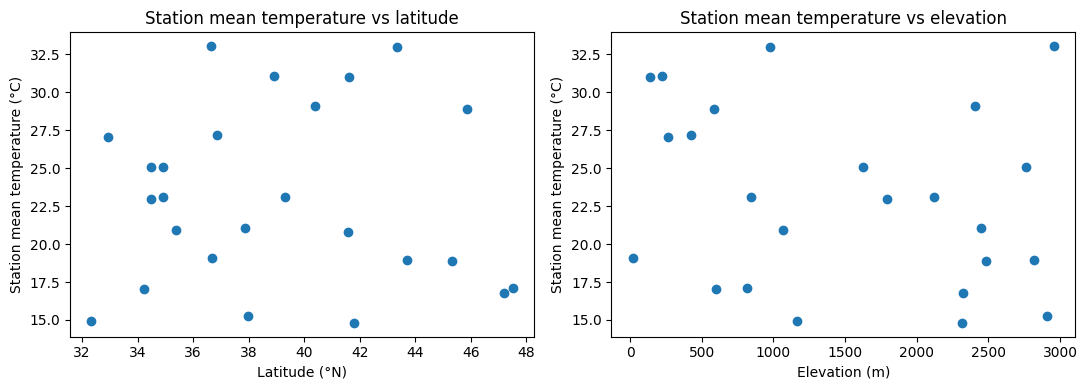

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, label in zip(axes, ["latitude", "elevation_m"], ["Latitude (°N)", "Elevation (m)"]):
    ax.scatter(station_summary[col], station_summary["avg_temp_c"])
    ax.set_xlabel(label)
    ax.set_ylabel("Station mean temperature (°C)")
    ax.set_title(f"Station mean temperature vs {label.split(' ')[0].lower()}")
plt.tight_layout()
plt.show()

### Part 4 answers

**Which region has the highest average temperature?** **North** with about 25.0 °C, followed by West at about 23.7 °C, South at about 23.1 °C, East at about 22.8 °C and Central at about 20.0 °C. Each region's value is very stable from year to year (within a few tenths of a degree).

**Which region has the largest average daily temperature range?** Technically **North** (~11.03 °C). However, all five regions lie between about 10.98 and 11.03 °C, a spread of only 0.05 °C. That is far smaller than the day to day variation in range (std ≈ 2.9 °C). **I would not claim any real regional difference in daily range**. The "largest" label is essentially noise.

**Interesting patterns and surprises**
- **The North is the warmest region, and latitude barely matters.** The correlation between station mean temperature and latitude is about −0.06. Elevation shows only a weak negative relationship (≈ −0.3). In real world data, northern and high elevation stations should be noticeably cooler. So the region labels here do not behave like real geography. For example, ST012 "Sunset Beach" is labelled South but is the northernmost station (47.5°N).
- **Differences within regions are much larger than differences between regions.** East contains both the warmest station (ST020, ~33 °C) and one of the coldest (ST001, ~15 °C). A regional average therefore hides a lot, and regions with few stations (West has only 3) are strongly influenced by individual stations.
- **The daily range is very uniform:** about 11 °C on average for every region, every station, and every month. Every station's maximum single day range is 15.8 to 16.0 °C. Real stations typically show larger ranges in dry or high elevation climates and seasonal changes in range. This uniformity, together with the over 50 °C readings, strongly suggests simulated data with a fixed range distribution.
- **The seasonal cycle is strong and in phase everywhere:** coldest in December with about ~8 °C, warmest in June with about ~38 °C, a roughly 30 °C swing. June has the largest average daily range about 11.07 °C, but again the monthly differences are only about 0.1 °C.
- All 25 stations have data in all 6 years, with 1,941 to 2,006 cleaned measurements each. So the quality filtering did not leave any station severely under represented.

**What characteristics of the data might explain these differences?** Station composition matters more than anything. Regional averages are averages of a few stations, each with its own baseline temperature (from ~15 °C to ~33 °C), and regions have different numbers of stations (3 to 8). The metadata (latitude, elevation) does not explain the baselines well. That means either unmeasured local factors or, more likely, that the data were generated without a physical link to location. Any conclusion like "the North is warmer" is a statement about *these particular stations*, not about real geography.

---
## Part 5: Time Series Analysis

### 5.1 Rolling 30-day average for one station

I use ST001 (Mountain View). For time series work I set `date` as the index and sort it.

After cleaning, the station is missing some days. So a window of 30 *rows* is not the same as 30 *calendar days*. I use a time based window (`rolling("30D")`), which always covers exactly the previous 30 calendar days, however many readings fall in it. `min_periods=20` avoids reporting an "average" based on only a handful of readings (for example, at the start of the series).

In [107]:
STATION = "ST001"

station_ts = (combined[combined["station_id"] == STATION]
              .set_index("date")
              .sort_index())

# Checking completeness of this station's daily record after cleaning
full_calendar = pd.date_range(station_ts.index.min(), station_ts.index.max(), freq="D")
print(f"Days in period: {len(full_calendar)}, days with data: {len(station_ts)}, "
      f"missing days: {len(full_calendar) - len(station_ts)}")
print("Gaps between consecutive readings (days):")
print(station_ts.index.to_series().diff().dt.days.value_counts().sort_index())

Days in period: 2191, days with data: 1982, missing days: 209
Gaps between consecutive readings (days):
date
1.0    1792
2.0     170
3.0      18
4.0       1
Name: count, dtype: int64


In [108]:
station_ts["rolling_30d"] = station_ts["temp_avg_c"].rolling("30D", min_periods=20).mean()
station_ts["rolling_30obs"] = station_ts["temp_avg_c"].rolling(30, min_periods=20).mean()

# Checking difference of the two definitions
difference = (station_ts["rolling_30d"] - station_ts["rolling_30obs"]).abs()
print(f"Mean absolute difference, 30 calendar days vs 30 observations: {difference.mean():.3f} °C")
print(f"Largest difference: {difference.max():.3f} °C")
station_ts[["temp_avg_c", "rolling_30d", "rolling_30obs"]].iloc[25:35]

Mean absolute difference, 30 calendar days vs 30 observations: 0.285 °C
Largest difference: 1.392 °C


,temp_avg_c,rolling_30d,rolling_30obs
date,,,
2018-01-30,3.6,2.25,2.25
2018-01-31,0.9,2.36,2.20
2018-02-02,6.9,2.48,2.36
2018-02-03,4.2,2.55,2.43
2018-02-05,4.6,2.49,2.50
2018-02-06,6.7,2.61,2.79
2018-02-07,-0.8,2.57,2.83
2018-02-09,4.7,2.97,2.71
2018-02-10,1.8,2.96,2.59


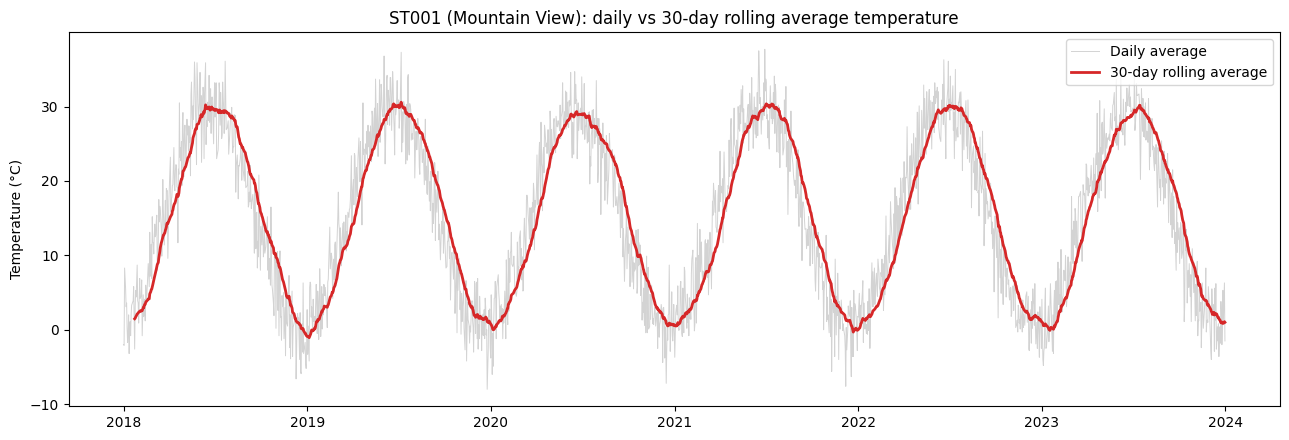

In [109]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(station_ts.index, station_ts["temp_avg_c"], color="lightgray", linewidth=0.7, label="Daily average")
ax.plot(station_ts.index, station_ts["rolling_30d"], color="tab:red", linewidth=2, label="30-day rolling average")
ax.set_title(f"{STATION} ({station_ts['station_name'].iloc[0]}): daily vs 30-day rolling average temperature")
ax.set_ylabel("Temperature (°C)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 5.2 Is there a longer term warming or cooling pattern?

All six years are complete, so annual means are comparable. I look at the chosen station, the network as a whole, and every station individually. To summarise a trend I fit a least squares line through the annual means (°C per year).

In [110]:
def trend_per_year(annual_series):
    """Slope of a least-squares line through annual means (°C per year)."""
    slope, _ = np.polyfit(annual_series.index, annual_series.values, deg=1)
    return slope

station_annual = station_ts["temp_avg_c"].resample("YS").mean()
station_annual.index = station_annual.index.year

network_annual = combined.groupby("year")["temp_avg_c"].mean()

annual = pd.DataFrame({f"{STATION}_avg_c": station_annual, "network_avg_c": network_annual})
annual.round(3)

,ST001_avg_c,network_avg_c
2018,15.33,23.10
2019,15.44,23.04
2020,15.19,22.98
2021,15.26,23.05
2022,15.32,23.01
2023,15.15,22.97


In [111]:
print(f"{STATION} trend: {trend_per_year(station_annual):+.3f} °C per year")
print(f"Network trend: {trend_per_year(network_annual):+.3f} °C per year")
print(f"Network: range of annual means = {network_annual.max() - network_annual.min():.3f} °C")

ST001 trend: -0.034 °C per year
Network trend: -0.019 °C per year
Network: range of annual means = 0.129 °C


In [112]:
# Trend for every station at once
station_year = combined.pivot_table(index="station_id", columns="year", values="temp_avg_c", aggfunc="mean")
years_centered = station_year.columns.values - station_year.columns.values.mean()
station_trends = (station_year.sub(station_year.mean(axis=1), axis=0) * years_centered).sum(axis=1) / (years_centered ** 2).sum()

print(station_trends.describe().round(3))
print("\nStations warming:", (station_trends > 0).sum(), "| cooling:", (station_trends < 0).sum())

count    25.00
mean     -0.02
std       0.07
min      -0.13
25%      -0.06
50%      -0.03
75%       0.04
max       0.08
dtype: float64

Stations warming: 11 | cooling: 14


In [113]:
# Checking the network 'trend' compared to normal year to year noise
# Comparing the size of the 2018 to 2023 change vs the typical year to year fluctuation at a single station
station_yoy = station_year.diff(axis=1)
print(f"Network change 2018→2023: {network_annual.iloc[-1] - network_annual.iloc[0]:+.3f} °C")
print(f"Typical single-station year-to-year change (std): {station_yoy.stack().std():.3f} °C")

Network change 2018→2023: -0.129 °C
Typical single-station year-to-year change (std): 0.385 °C


### 5.3 Year over year changes

In [114]:
yoy = pd.DataFrame({
    f"{STATION}_avg_c": station_annual,
    f"{STATION}_yoy_change_c": station_annual.diff(),
    "network_avg_c": network_annual,
    "network_yoy_change_c": network_annual.diff(),
})
yoy.round(3)

,ST001_avg_c,ST001_yoy_change_c,network_avg_c,network_yoy_change_c
2018,15.33,NaN,23.10,NaN
2019,15.44,0.10,23.04,-0.06
2020,15.19,-0.24,22.98,-0.06
2021,15.26,0.06,23.05,0.06
2022,15.32,0.06,23.01,-0.04
2023,15.15,-0.17,22.97,-0.04


In [115]:
# Year over year change for each region
region_yoy = region_year.drop(columns="mean_of_yearly_avgs").diff(axis=1)
region_yoy.round(2)

year,2018,2019,2020,2021,2022,2023
region,,,,,,
Central,NaN,0.03,-0.17,0.27,-0.30,-0.03
East,NaN,-0.01,-0.15,0.05,0.06,-0.15
North,NaN,0.12,-0.20,0.20,-0.12,0.08
South,NaN,-0.26,0.10,-0.21,0.10,0.32
West,NaN,-0.35,0.28,0.03,-0.02,-0.47


I report year over year changes as differences in °C, not percentage changes. Celsius has an arbitrary zero point, so "a 1% increase" in Celsius temperature is not meaningful.

### 5.4 Seasonal patterns in temperature range

I group the daily range by season (Dec–Feb = Winter, and so on) and by month, and show the spread (standard deviation) as well as the mean. This shows whether the variability changes by season, not just the level.

In [116]:
season_map = {12: "Winter", 1: "Winter", 2: "Winter",
              3: "Spring", 4: "Spring", 5: "Spring",
              6: "Summer", 7: "Summer", 8: "Summer",
              9: "Autumn", 10: "Autumn", 11: "Autumn"}
combined["season"] = combined["month"].map(season_map)

season_order = ["Winter", "Spring", "Summer", "Autumn"]
seasonal_range = (combined.groupby("season")
                  .agg(avg_temp_c=("temp_avg_c", "mean"),
                       avg_range_c=("temp_range_c", "mean"),
                       std_range_c=("temp_range_c", "std"),
                       max_range_c=("temp_range_c", "max"))
                  .reindex(season_order))
seasonal_range.round(2)

,avg_temp_c,avg_range_c,std_range_c,max_range_c
season,,,,
Winter,10.81,11.00,2.04,15.9
Spring,28.82,10.97,2.06,16.0
Summer,35.14,11.01,2.04,16.0
Autumn,17.04,11.02,2.03,16.0


In [117]:
# Checking if any region show a seasonal cycle in range
combined.pivot_table(index="region", columns="month", values="temp_range_c", aggfunc="mean").round(2)

month,1,2,3,4,5,6,7,8,9,10,11,12
region,,,,,,,,,,,,
Central,11.04,10.88,10.90,10.87,10.97,11.13,11.02,10.94,11.04,11.01,10.94,10.98
East,11.04,10.94,10.95,11.03,10.90,11.03,10.96,10.89,10.95,11.04,10.96,11.06
North,10.99,11.08,11.05,11.02,10.94,11.14,10.94,11.08,11.11,10.99,11.02,11.01
South,10.99,10.94,11.05,10.89,10.96,10.94,11.07,11.04,11.04,11.18,11.07,11.02
West,11.02,10.88,10.98,10.99,11.11,11.12,11.02,11.04,10.99,11.07,10.93,10.95


### 5.5 Resample to monthly averages and visualise

`resample("MS")` groups the daily data into calendar months (labelled by month start). For the network and regional lines, I resample within each group with `groupby(...).resample(...)`. That way each series is a proper monthly average of its own measurements.

In [118]:
combined_ts = combined.set_index("date").sort_index()

network_monthly = combined_ts["temp_avg_c"].resample("MS").mean()
station_monthly = station_ts["temp_avg_c"].resample("MS").mean()
region_monthly = (combined_ts.groupby("region")["temp_avg_c"]
                  .resample("MS").mean()
                  .unstack(level="region"))
range_monthly = combined_ts["temp_range_c"].resample("MS").mean()

print("Months in resampled series:", len(network_monthly))
region_monthly.head()

Months in resampled series: 72


region,Central,East,North,South,West
date,,,,,
2018-01-01,6.39,9.86,12.00,9.78,10.25
2018-02-01,11.65,14.12,17.23,14.28,15.27
2018-03-01,18.74,21.77,23.64,21.94,22.99
2018-04-01,26.38,29.28,31.06,29.76,30.02
2018-05-01,32.48,35.01,36.98,34.98,36.06


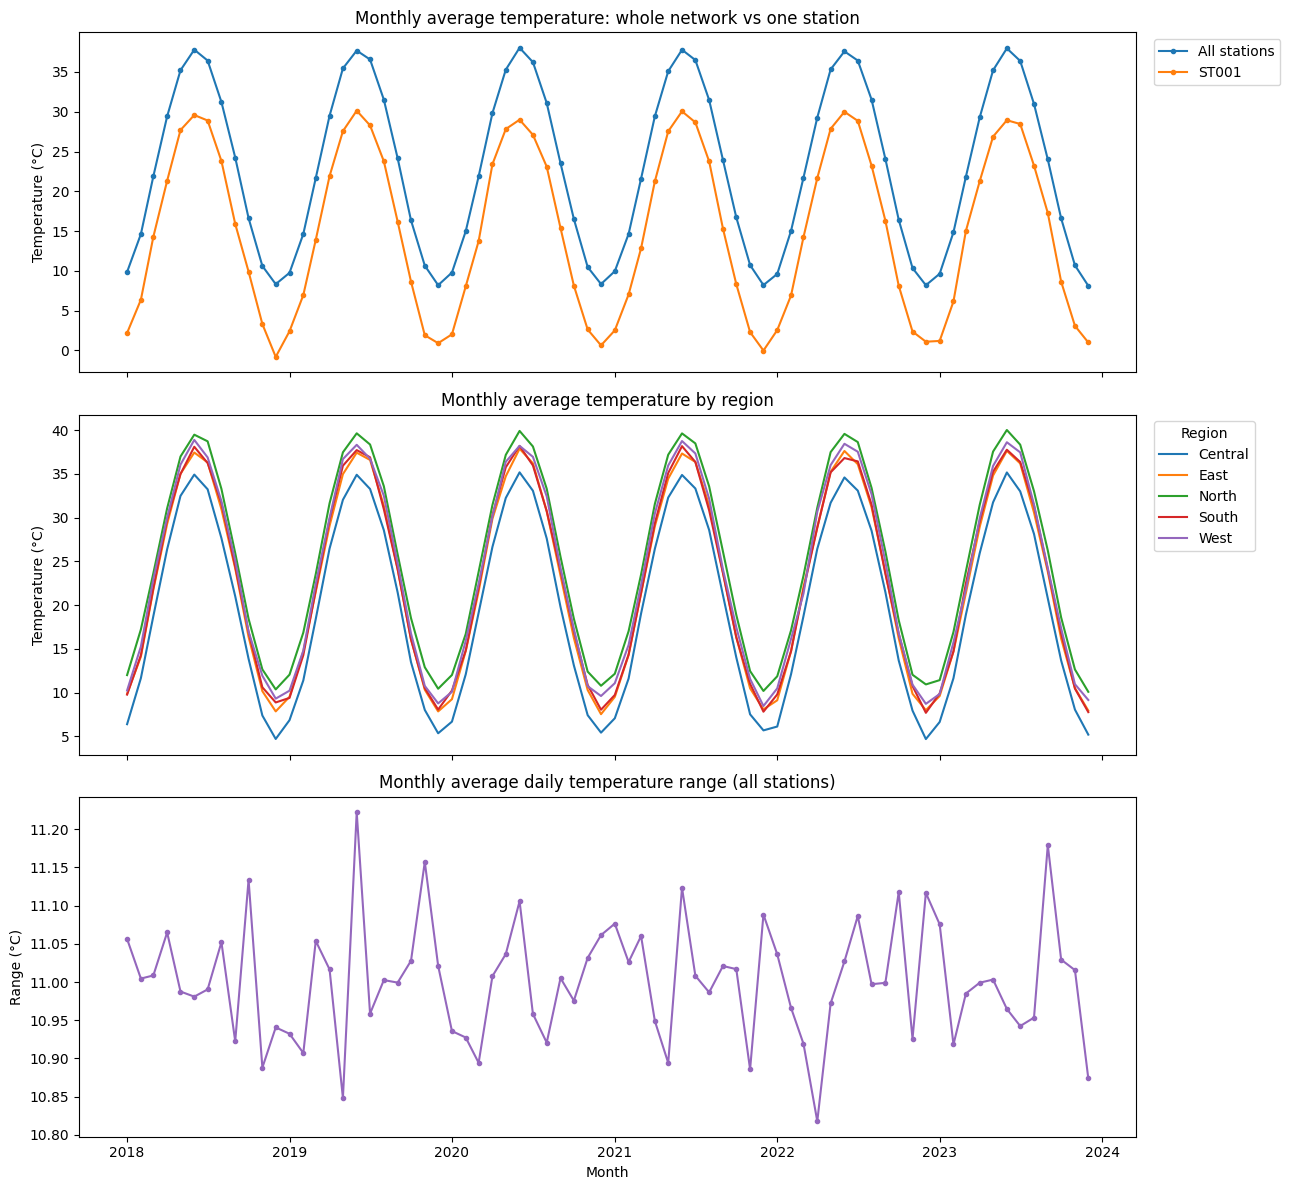

In [119]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)

# (1) Network vs selected station
axes[0].plot(network_monthly.index, network_monthly, marker="o", markersize=3, label="All stations")
axes[0].plot(station_monthly.index, station_monthly, marker="o", markersize=3, label=f"{STATION}")
axes[0].set_title("Monthly average temperature: whole network vs one station")
axes[0].set_ylabel("Temperature (°C)")
axes[0].legend(loc="upper left", bbox_to_anchor=(1.01, 1))

# (2) By region
for region in region_monthly.columns:
    axes[1].plot(region_monthly.index, region_monthly[region], label=region)
axes[1].set_title("Monthly average temperature by region")
axes[1].set_ylabel("Temperature (°C)")
axes[1].legend(title="Region", loc="upper left", bbox_to_anchor=(1.01, 1))

# (3) Monthly average daily range plotted on its own axis so small changes are visible
axes[2].plot(range_monthly.index, range_monthly, color="tab:purple", marker="o", markersize=3)
axes[2].set_title("Monthly average daily temperature range (all stations)")
axes[2].set_ylabel("Range (°C)")
axes[2].set_xlabel("Month")

plt.tight_layout()
plt.show()

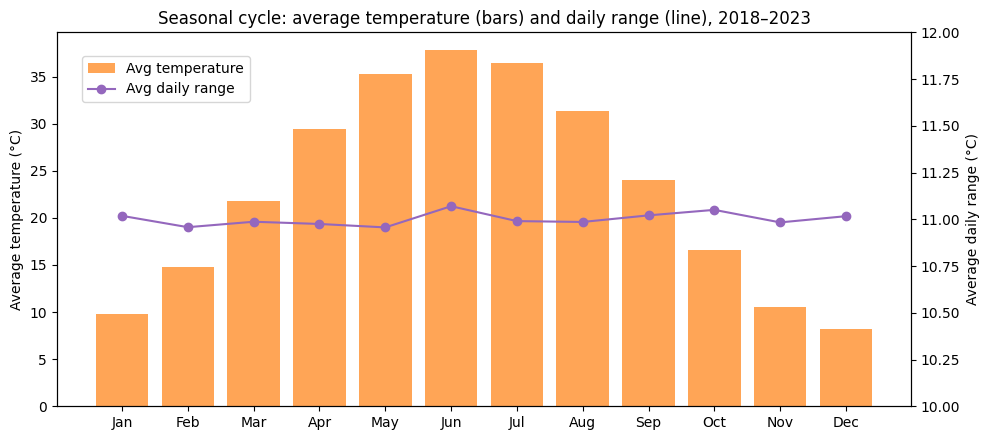

In [120]:
# Seasonal cycle, averaged over the six years
fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.bar(monthly.index, monthly["avg_temp_c"], color="tab:orange", alpha=0.7, label="Avg temperature")
ax1.set_ylabel("Average temperature (°C)")
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["avg_daily_range_c"], color="tab:purple", marker="o", label="Avg daily range")
ax2.set_ylabel("Average daily range (°C)")
ax2.set_ylim(10, 12)
ax1.set_title("Seasonal cycle: average temperature (bars) and daily range (line), 2018–2023")
fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.88))
plt.tight_layout()
plt.show()

### Part 5 answers

**How does a rolling average change the picture compared with daily data?** Daily values at ST001 jump several degrees from one day to the next. That hides the underlying signal. The 30 day rolling mean filters out the short term weather and shows the annual cycle, so it is easy to see the timing of the seasonal peak and trough and whether the same pattern repeats each year. The tradeoff is lag and the loss of extremes. I also showed that the choice of window matters. With gaps in the data, a 30-*observation* window can stretch past 30 days, so I used a 30-*calendar-day* window. Here the two differ by about 0.3 °C on average (up to ~1.4 °C around the spring and autumn transitions), because the gaps are mostly only 1 to 2 days.

**What seasonal patterns do I observe?** A strong, regular annual cycle at every station and in every region. The network is coldest in December and January at about 8-10 °C and warmest in June at about 38 °C, with the same timing every year. The regions differ in their level, not in the shape of the cycle. The daily temperature range, by contrast, shows essentially no seasonal pattern. Seasonal means differ by less than 0.1 °C, and the spread and maximum range are the same in every season. In real climates the range usually varies by season (for example, larger in dry seasons), so this lack of pattern is a finding in itself.

**Is there evidence of warming or cooling?** **No meaningful evidence either way.** The network annual mean moves between about 22.97 and 23.10 °C, and the fitted slope is about −0.02 °C per year. ST001 shows a similarly tiny slope. Across the 25 stations, individual trends go both ways. The total change 2018→2023 is smaller than the normal year to year fluctuation at a single station. I would describe the record as **stable**, not warming or cooling.

**What does the year over year analysis show?** Network changes are small, of both signs (roughly −0.06 to +0.06 °C), with no sustained run in one direction. Regional and single station changes are larger but also switch sign from year to year. This looks like ordinary variability, not a directional trend.

**Limitations to consider**
- **Six years is far too short for climate trends.** Climate trends are normally assessed over 30+ years. Natural variability can easily produce multi year swings of this size.
- **Six annual data points** give a regression slope with very large uncertainty. I did not compute a formal significance test, and with n = 6 any test would have very little power.
- **Filtering creates gaps.** If poor quality readings cluster in particular conditions (e.g., extreme heat or cold), removing them could bias the means. I have not verified that gaps are random.
- **Imputed averages** About 0.9% of rows are estimates.
- **Data plausibility:** readings above 50–60 °C and the lack of any relationship between temperature and latitude suggest these are simulated data. Any conclusions describe this dataset, not the real climate of the listed locations.
- **Station-level results don't generalise:** results for ST001 describe one station. Regional results depend on only 3–8 stations each.

---
## Summary of key decisions

| Decision | Choice | Reason |
|---|---|---|
| Quality filter | Keep `good` + `fair`, drop `poor` and unflagged (`NaN`) | An unflagged reading has unknown reliability, like the "missing" category |
| Order of cleaning | Filter quality before deduplication | A duplicate can never keep a poor quality copy |
| Missing `temp_avg_c` | Fill with `(max + min) / 2` and flag | Max/min always present. Midpoint matches the recorded average with no bias |
| Missing station name | Placeholder `"Unknown name"` | Prevents `groupby` from silently dropping ST018 |
| Join | Left join, `validate="many_to_one"`, `indicator=True` | Keeps every measurement, proves no rows were added or left unmatched |
| Rolling window | `rolling("30D")` on a date index | Gaps after cleaning make 30 rows does not equal 30 days |
| Year-over-year change | Differences in °C, not % | Celsius has an arbitrary zero |